In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

Connecting Google Drive...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive connected successfully!

Searching for age_insurance.csv...

File found!
Location: /content/drive/MyDrive/Colab/age_insurance.csv

Dataset loaded successfully!

First 5 rows:
   Age  Insurance  InsurancePlan
0   56          0              0
1   69          1              2
2   46          1              2
3   32          0              0
4   60          1              2

Dataset shape:
(300, 3)

Column names:
['Age', 'Insurance', 'InsurancePlan']

Column names after cleaning:
['Age', 'Insurance', 'InsurancePlan']


PART 1: BINARY LOGISTIC REGRESSION

Feature: Age
Target: Insurance
0 = No Insurance
1 = Has Insurance

Training samples: 240
Testing samples: 60

Model trained successfully!

Accuracy:
0.7833333333333333

Classification Report:
               precision    recall  f1-score   support

 No Insurance       0.77  

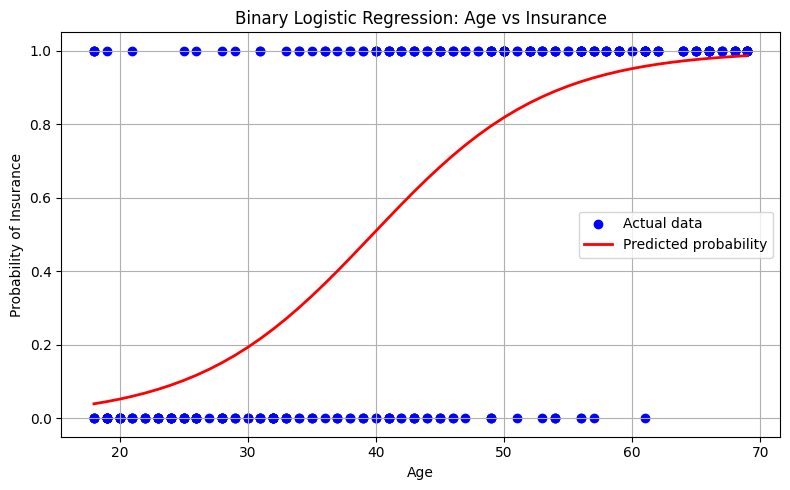



PROGRAM COMPLETED SUCCESSFULLY!


In [16]:
# =========================================================
# BINARY LOGISTIC REGRESSION - AGE vs INSURANCE
# Google Colab + Google Drive
# =========================================================

# ---------------------------------------------------------
# STEP 1: Import libraries
# ---------------------------------------------------------

import os
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


# ---------------------------------------------------------
# STEP 2: Mount Google Drive
# ---------------------------------------------------------

print("Connecting Google Drive...")

drive.mount('/content/drive')

print("Google Drive connected successfully!")


# ---------------------------------------------------------
# STEP 3: Find age_insurance.csv automatically
# ---------------------------------------------------------

print("\nSearching for age_insurance.csv...")

file_path = None

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.lower() == 'age_insurance.csv':
            file_path = os.path.join(root, file)
            break

    if file_path is not None:
        break


# ---------------------------------------------------------
# STEP 4: Check whether file was found
# ---------------------------------------------------------

if file_path is None:

    print("\nERROR: age_insurance.csv was not found!")
    print("\nPlease make sure the CSV file is somewhere inside")
    print("Google Drive -> My Drive")

else:

    print("\nFile found!")
    print("Location:", file_path)


    # -----------------------------------------------------
    # STEP 5: Load the dataset
    # -----------------------------------------------------

    df = pd.read_csv(file_path)

    print("\nDataset loaded successfully!")


    # -----------------------------------------------------
    # STEP 6: Display dataset information
    # -----------------------------------------------------

    print("\nFirst 5 rows:")
    print(df.head())

    print("\nDataset shape:")
    print(df.shape)

    print("\nColumn names:")
    print(df.columns.tolist())


    # -----------------------------------------------------
    # STEP 7: Clean column names
    # -----------------------------------------------------

    df.columns = df.columns.str.strip()

    print("\nColumn names after cleaning:")
    print(df.columns.tolist())


    # -----------------------------------------------------
    # STEP 8: Check required columns
    # -----------------------------------------------------

    if "Age" not in df.columns or "Insurance" not in df.columns:

        print("\nERROR!")
        print("Your dataset must contain these columns:")
        print("Age")
        print("Insurance")

        print("\nYour actual columns are:")
        print(df.columns.tolist())

    else:

        # =================================================
        # PART 1: BINARY LOGISTIC REGRESSION
        # =================================================

        print("\n")
        print("=" * 60)
        print("PART 1: BINARY LOGISTIC REGRESSION")
        print("=" * 60)

        print("\nFeature: Age")
        print("Target: Insurance")
        print("0 = No Insurance")
        print("1 = Has Insurance")


        # -------------------------------------------------
        # STEP 9: Select feature and target
        # -------------------------------------------------

        X = df[["Age"]]
        y = df["Insurance"]


        # -------------------------------------------------
        # STEP 10: Split dataset
        # -------------------------------------------------

        X_train, X_test, y_train, y_test = train_test_split(
            X,
            y,
            test_size=0.2,
            random_state=42
        )

        print("\nTraining samples:", len(X_train))
        print("Testing samples:", len(X_test))


        # -------------------------------------------------
        # STEP 11: Create Logistic Regression model
        # -------------------------------------------------

        binary_model = LogisticRegression()


        # -------------------------------------------------
        # STEP 12: Train model
        # -------------------------------------------------

        binary_model.fit(X_train, y_train)

        print("\nModel trained successfully!")


        # -------------------------------------------------
        # STEP 13: Predict test data
        # -------------------------------------------------

        y_pred = binary_model.predict(X_test)


        # -------------------------------------------------
        # STEP 14: Accuracy
        # -------------------------------------------------

        accuracy = accuracy_score(y_test, y_pred)

        print("\nAccuracy:")
        print(accuracy)


        # -------------------------------------------------
        # STEP 15: Classification Report
        # -------------------------------------------------

        print("\nClassification Report:")

        print(
            classification_report(
                y_test,
                y_pred,
                target_names=[
                    "No Insurance",
                    "Has Insurance"
                ]
            )
        )


        # -------------------------------------------------
        # STEP 16: Confusion Matrix
        # -------------------------------------------------

        print("Confusion Matrix:")

        cm = confusion_matrix(y_test, y_pred)

        print(cm)


        # -------------------------------------------------
        # STEP 17: Predict for new people
        # -------------------------------------------------

        new_age = pd.DataFrame({
            "Age": [22, 45, 63]
        })

        predictions = binary_model.predict(new_age)

        probabilities = binary_model.predict_proba(new_age)[:, 1]


        print("\n")
        print("=" * 60)
        print("PREDICTIONS FOR NEW PEOPLE")
        print("=" * 60)


        for age_val, pred, prob in zip(
            new_age["Age"],
            predictions,
            probabilities
        ):

            insurance_status = (
                "Has Insurance"
                if pred == 1
                else "No Insurance"
            )

            print(
                f"Age {age_val}: "
                f"{insurance_status} "
                f"(Probability of Yes = {prob:.2f})"
            )


        # =================================================
        # STEP 18: Logistic Regression S-Curve
        # =================================================

        plt.figure(figsize=(8, 5))


        # Actual data
        plt.scatter(
            df["Age"],
            df["Insurance"],
            color="blue",
            label="Actual data"
        )


        # Age range
        min_age = int(df["Age"].min())
        max_age = int(df["Age"].max())

        age_range = pd.DataFrame({
            "Age": range(min_age, max_age + 1)
        })


        # Predicted probability
        predicted_probability = binary_model.predict_proba(
            age_range
        )[:, 1]


        # S-curve
        plt.plot(
            age_range["Age"],
            predicted_probability,
            color="red",
            linewidth=2,
            label="Predicted probability"
        )


        plt.xlabel("Age")
        plt.ylabel("Probability of Insurance")
        plt.title(
            "Binary Logistic Regression: Age vs Insurance"
        )

        plt.legend()
        plt.grid(True)
        plt.tight_layout()


        # -------------------------------------------------
        # STEP 19: Save graph
        # -------------------------------------------------

        plot_path = "/content/drive/MyDrive/binary_logistic_plot.png"

        plt.savefig(plot_path)

        print("\nGraph saved to:")
        print(plot_path)


        # Display graph
        plt.show()


        # =================================================
        # STEP 20: Final result
        # =================================================

        print("\n")
        print("=" * 60)
        print("PROGRAM COMPLETED SUCCESSFULLY!")
        print("=" * 60)
